# Sequence-to-Sequence Learning with an LSTM Encoder–Decoder

A **sequence-to-sequence (seq2seq)** model maps one variable-length sequence to another. Examples include machine translation, summarization, dialogue, and converting speech into text.

In this notebook we build a small German-to-English translator from first principles with PyTorch. The dataset is deliberately small and self-contained: the objective is to understand the architecture and tensor flow, not to produce a production-quality translator.

### Learning objectives

By the end, you should be able to explain and implement:

- source and target sequences, special tokens, vocabularies, and padding;
- an LSTM encoder that compresses a source sequence into context states;
- an LSTM decoder that generates one target token at a time;
- teacher forcing during training and autoregressive decoding during inference;
- masked cross-entropy loss, gradient clipping, validation, and greedy translation; and
- the limitations of a fixed-context encoder–decoder and why attention is useful.

> Recommended prerequisites: `RNNs.md`, `GRUs.ipynb`, and `LSTMs.ipynb`.

## 1. The sequence-to-sequence task

Let the source sequence be

$$X=(x_1,x_2,\ldots,x_{T_x})$$

and the target sequence be

$$Y=(y_1,y_2,\ldots,y_{T_y}).$$

The lengths $T_x$ and $T_y$ do not need to be equal. For example:

```text
source (German):  heute sehe ich das haus
target (English): today i see the house
```

We add boundary tokens:

```text
<sos> heute sehe ich das haus <eos>
<sos> today i see the house <eos>
```

`<sos>` tells the decoder to begin. `<eos>` teaches it when to stop. `<pad>` makes sequences in a batch equally long, and `<unk>` represents tokens absent from the training vocabulary.

## 2. Encoder–decoder architecture

The model contains two recurrent networks:

1. The **encoder** reads the complete source sequence.
2. The **decoder** uses the encoder's final state to generate the target sequence one token at a time.

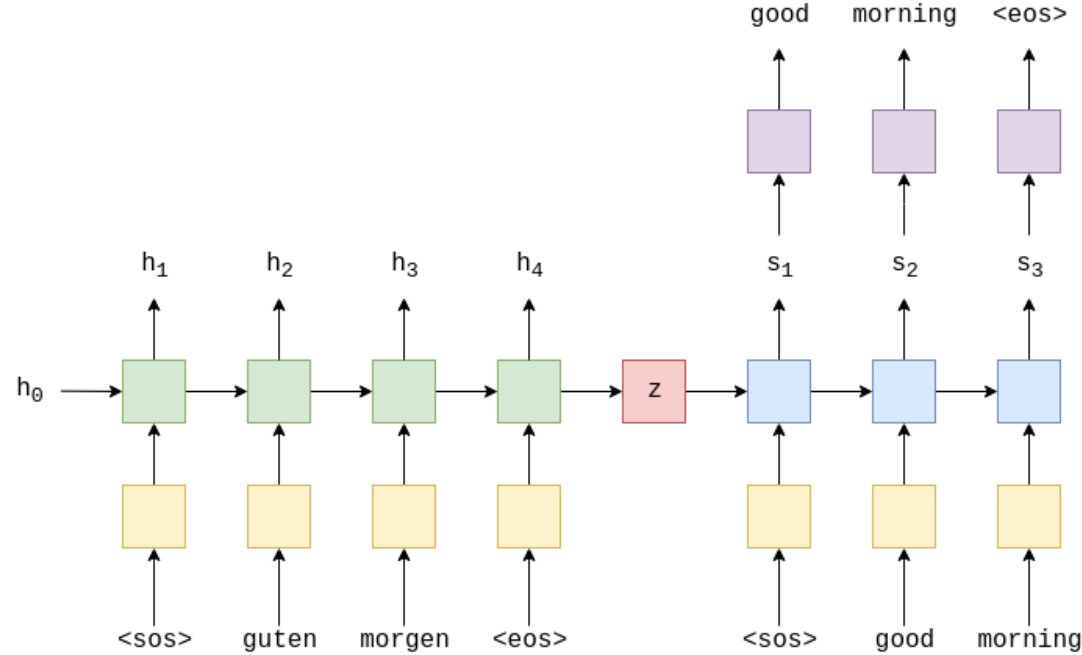

```text
source token IDs
      │
      ▼
source embeddings → encoder LSTM → (h_T, c_T)
                                      │
                              context │ states
                                      ▼
<sos> → decoder LSTM → token logits → predicted token
              ▲                              │
              └──────────────────────────────┘
                    next decoding step
```

For an LSTM, the context is a pair:

$$z=(h_{T_x},c_{T_x}).$$

$h_{T_x}$ is the final hidden state and $c_{T_x}$ is the final cell state. They initialize the decoder. This first architecture passes only the final states to the decoder; later we discuss why compressing the whole source into fixed-size states becomes a bottleneck.

## 3. Setup and reproducibility

Fixing random seeds makes this small demonstration easier to reproduce. Exact results can still vary across PyTorch versions and hardware.

In [1]:
import copy
import math
import random
from collections import Counter

import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset

SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 4. Parallel text data

Translation training requires **parallel data**: each source sentence is paired with its target translation. Here we generate a tiny, regular corpus so the entire notebook works offline. Real translation systems use much larger and more diverse corpora.

In [2]:
# Map German words (dictionary keys) to English words (dictionary values).
# We use four nouns and four colours to build a small dataset without downloads.
nouns = {
    "auto": "car",
    "buch": "book",
    "haus": "house",
    "boot": "boat",
}
colors = {
    "rot": "red",
    "blau": "blue",
    "grün": "green",
    "gelb": "yellow",
}

# Each entry will be a tuple: (German source sentence, English target sentence).
pairs = []

# .items() gives each German word and its English translation together.
for de_noun, en_noun in nouns.items():
    # Combine the current noun with every colour: four sentence pairs per noun.
    for de_color, en_color in colors.items():
        # f-strings insert the current words into the sentence templates.
        # Example: ("das buch ist rot", "the book is red").
        # append() adds this ONE sentence pair to the list.
        pairs.append((f"das {de_noun} ist {de_color}", f"the {en_noun} is {en_color}"))

    # Add four more sentence patterns for the current noun.
    # This is outside the colour loop, so these are added only once per noun.
    # extend() adds EACH of the four pairs below to the existing list.
    pairs.extend(
        [
            (f"ich sehe das {de_noun}", f"i see the {en_noun}"),
            (f"heute sehe ich das {de_noun}", f"today i see the {en_noun}"),
            (f"morgen sehe ich das {de_noun}", f"tomorrow i see the {en_noun}"),
            (f"wir haben das {de_noun}", f"we have the {en_noun}"),
        ]
    )

# Total: 4 nouns x (4 colour sentences + 4 other sentences) = 32 pairs.
# Mix the list in place before splitting; each translation pair stays together.
# The random seed set earlier makes the shuffle reproducible when run in order.
random.shuffle(pairs)

# Python slices include the start index but exclude the end index.
train_pairs = pairs[:24]    # First 24 pairs: used to learn model parameters.
valid_pairs = pairs[24:28]  # Next 4 pairs: used to select the best training checkpoint.
test_pairs = pairs[28:]     # Remaining 4 pairs: used for final evaluation.

# Show the number of examples in each split and preview three training pairs.
print(f"train={len(train_pairs)}, valid={len(valid_pairs)}, test={len(test_pairs)}")
for source, target in train_pairs[:3]:
    # :28s reserves at least 28 characters for the source, aligning the arrows.
    print(f"{source:28s} -> {target}")


train=24, valid=4, test=4
ich sehe das boot            -> i see the boat
das buch ist blau            -> the book is blue
das haus ist gelb            -> the house is yellow


## 5. Tokenization and vocabularies

A tokenizer converts text into tokens. A vocabulary then maps tokens to integer IDs because neural networks operate on numbers, not strings. Source and target languages need separate vocabularies and embedding layers.

Vocabularies should be built from the **training split only**. Including validation or test text would leak information about evaluation data. Our whitespace tokenizer is sufficient for this controlled corpus; real data benefits from a proper tokenizer or a subword method such as BPE/SentencePiece.

In [3]:
# Special tokens have specific roles when we prepare and generate sequences.
PAD_TOKEN = "<pad>"  # Fills unused positions so sentences in a batch have equal length.
UNK_TOKEN = "<unk>"  # Represents a word that is absent from the vocabulary.
SOS_TOKEN = "<sos>"  # Marks the start of a sequence; the decoder starts with this token.
EOS_TOKEN = "<eos>"  # Marks the end of a sequence; tells the decoder when to stop.

# Putting these first gives them fixed IDs: <pad>=0, <unk>=1, <sos>=2, <eos>=3.
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN]

def tokenize(text):
    # Convert to lowercase, then split on whitespace.
    # Example: "Das Buch ist ROT" -> ["das", "buch", "ist", "rot"].
    # This simple tokenizer does not separate punctuation from words.
    return text.lower().split()

def build_vocab(sentences, min_frequency=1):
    # Visit every sentence, tokenize it, and count how often each token occurs.
    # The nested expression reads: for each sentence, for each token in that sentence.
    # Counter stores results such as {"das": 20, "buch": 6, ...}.
    counts = Counter(token for sentence in sentences for token in tokenize(sentence))

    # Keep words that occur at least min_frequency times (default: keep every word).
    # Sort the retained words alphabetically for a consistent order, then place
    # them after the four special tokens. Each word appears only once in this list.
    tokens = SPECIAL_TOKENS + sorted(
        token for token, count in counts.items() if count >= min_frequency
    )

    # enumerate() assigns an integer position to each token, starting at zero.
    # stoi means "string to integer": look up a token to get its ID.
    # Example: stoi["<sos>"] returns 2.
    stoi = {token: index for index, token in enumerate(tokens)}

    # Return both lookup directions: token -> ID (dictionary), ID -> token (list).
    # For example, tokens[2] returns "<sos>".
    return stoi, tokens

# Build separate vocabularies for German (source) and English (target).
# Use only training sentences so validation/test words do not influence vocabulary.
# Each expression below extracts one side of every (source, target) pair.
# The underscore (_) names the side we do not need in that expression.
# itos means "integer to string": the returned token list supports lookup by ID.
source_stoi, source_itos = build_vocab(source for source, _ in train_pairs)
target_stoi, target_itos = build_vocab(target for _, target in train_pairs)

# Save frequently used special-token IDs for padding, loss calculation, and decoding.
# These IDs match across the two vocabularies because SPECIAL_TOKENS comes first
# in the same order in both. Ordinary German and English word IDs need not match.
PAD_IDX = target_stoi[PAD_TOKEN]  # special-token indices match in both vocabularies
SOS_IDX = target_stoi[SOS_TOKEN]
EOS_IDX = target_stoi[EOS_TOKEN]

# Vocabulary sizes include the four special tokens.
print("source vocabulary size:", len(source_itos))
print("target vocabulary size:", len(target_itos))
# Build and display a small dictionary containing only the special-token mappings.
print("special-token IDs:", {token: target_stoi[token] for token in SPECIAL_TOKENS})


source vocabulary size: 20
target vocabulary size: 20
special-token IDs: {'<pad>': 0, '<unk>': 1, '<sos>': 2, '<eos>': 3}


## 6. Numericalization, padding, and batching

**Numericalization** converts tokens to vocabulary IDs. A batch requires a rectangular tensor, so shorter sequences are padded to the longest sequence in that batch.

With `batch_first=True`, our tensors have shapes:

| Tensor | Shape |
|---|---|
| Source IDs | $(B,T_x)$ |
| Target IDs | $(B,T_y)$ |
| Source lengths | $(B,)$ |

We retain the true source lengths so the encoder can use a packed sequence and avoid treating padding as real input.

In [4]:
# Convert one sentence into a one-dimensional tensor of vocabulary IDs.
# stoi is the token-to-ID dictionary for the sentence's language.
def numericalize(text, stoi):
    # Use the <unk> ID if a word is not in the training vocabulary.
    unk_index = stoi[UNK_TOKEN]
    # Begin with <sos>, then add one ID per token in the sentence.
    token_ids = [stoi[SOS_TOKEN]]
    # Dictionary .get() returns unk_index when the token is missing.
    token_ids += [stoi.get(token, unk_index) for token in tokenize(text)]
    # Append <eos> so the sequence has an explicit ending.
    token_ids.append(stoi[EOS_TOKEN])
    # Embedding layers expect integer indices; torch.long is a 64-bit integer type.
    # Shape: (sentence length including <sos> and <eos>,). No padding yet.
    return torch.tensor(token_ids, dtype=torch.long)

# Adapt our list of text pairs to the interface expected by a PyTorch DataLoader.
class TranslationDataset(Dataset):
    def __init__(self, sentence_pairs):
        # Store the original (German sentence, English sentence) pairs.
        self.sentence_pairs = sentence_pairs

    def __len__(self):
        # len(dataset) returns the number of sentence pairs, not the token count.
        return len(self.sentence_pairs)

    def __getitem__(self, index):
        # dataset[index] retrieves one source/target pair and converts both to IDs.
        # Each language uses its own vocabulary; their lengths may differ.
        source, target = self.sentence_pairs[index]
        return numericalize(source, source_stoi), numericalize(target, target_stoi)

# DataLoader calls this function to combine a list of examples into one batch.
def collate_batch(examples):
    # examples looks like [(source1, target1), (source2, target2), ...].
    # * unpacks the list; zip groups all sources together and all targets together.
    source_sequences, target_sequences = zip(*examples)

    # Record lengths BEFORE padding, including <sos> and <eos>.
    # One integer per source sentence gives shape (B,), where B is the batch size.
    # Example: three sentences with lengths 6, 7, 5 give tensor([6, 7, 5]).
    # The encoder later uses these lengths to skip padded source positions.
    source_lengths = torch.tensor([len(sequence) for sequence in source_sequences])

    # Add <pad> IDs on the right up to the longest source length in this batch.
    # batch_first=True puts sentences in rows: shape (B, T_x).
    # For lengths [6, 7, 5], this gives shape (3, 7).
    source_batch = pad_sequence(source_sequences, batch_first=True, padding_value=PAD_IDX)
    # Pad targets separately: shape (B, T_y). T_y need not equal T_x.
    # PAD_IDX works for both languages because their special-token IDs match.
    # Target padding will be ignored by the loss function later in the notebook.
    target_batch = pad_sequence(target_sequences, batch_first=True, padding_value=PAD_IDX)
    # Corresponding source and target rows still form a translation pair.
    return source_batch, source_lengths, target_batch

# Create a loader that supplies batches when we iterate over it.
def make_loader(sentence_pairs, shuffle=False, batch_size=8):
    return DataLoader(
        TranslationDataset(sentence_pairs),  # Converts individual text pairs to IDs.
        batch_size=batch_size,               # Up to 8 pairs; the last batch may be smaller.
        shuffle=shuffle,                     # Whether to randomize the order of pairs.
        collate_fn=collate_batch,             # Our function pads and combines each batch.
    )

# Shuffle training pairs on each new pass through the loader, keeping pairs intact.
train_loader = make_loader(train_pairs, shuffle=True)
# Validation/test loaders keep their original order (shuffle=False by default).
valid_loader = make_loader(valid_pairs)
test_loader = make_loader(test_pairs)


In [5]:
# iter() starts a pass through the training loader; next() retrieves its first batch.
# Unpack the three tensors returned by collate_batch().
source_batch, source_lengths, target_batch = next(iter(train_loader))
# B = number of sentence pairs; T_x/T_y = longest source/target lengths in this batch.
print("source batch:  ", source_batch.shape)  # (B, T_x): one padded source per row.
# (B,) means a one-dimensional vector with one unpadded length per source sentence.
# .tolist() converts the tensor to a Python list so its values are easy to inspect.
print("source lengths:", source_lengths.shape, source_lengths.tolist())
print("target batch:  ", target_batch.shape)  # (B, T_y): one padded target per row.
# Index 0 selects the first source sentence, including any padding added to it.
print("first source IDs:", source_batch[0].tolist())
# Reverse the ID mapping to see the tokens, including <sos>, <eos>, and any <pad>.
print("first source tokens:", [source_itos[i] for i in source_batch[0].tolist()])


source batch:   torch.Size([8, 7])
source lengths: torch.Size([8]) [6, 6, 7, 6, 7, 6, 6, 6]
target batch:   torch.Size([8, 7])
first source IDs: [2, 8, 4, 15, 9, 3, 0]
first source tokens: ['<sos>', 'das', 'auto', 'ist', 'gelb', '<eos>', '<pad>']


## 7. The LSTM encoder

The **encoder reads a German source sentence and produces two state tensors, `hidden` and `cell`**. The decoder will use these states to start generating the English translation. The encoder does not predict English words itself.

```text
Source token IDs → Embedding → Dropout → Packed sequence → Encoder LSTM
                                                               │
                                                               ▼
                                                        (hidden, cell)
                                                               │
                                                               ▼
                                                   Initial states of decoder
```

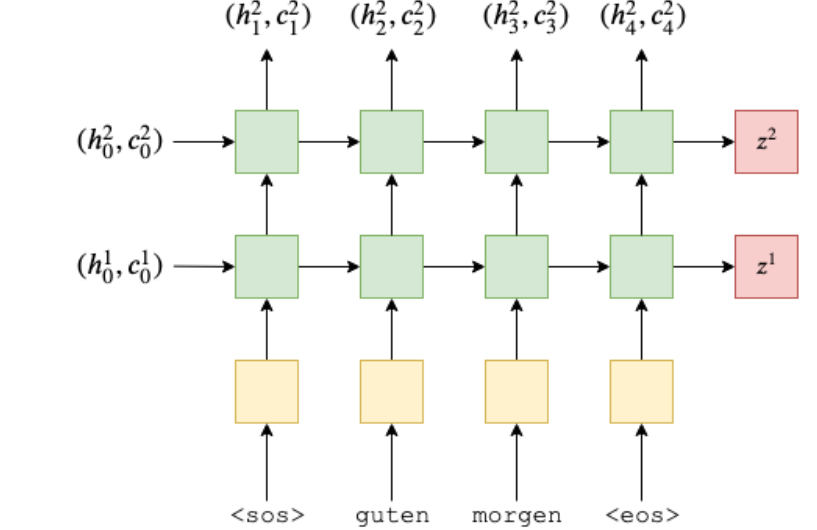

### Step 1: Convert token IDs into learned vectors

A token ID is just a vocabulary label: a larger ID does not mean a word has a larger meaning. `nn.Embedding` looks up a vector for each ID. These vectors are learned during training together with the rest of the model.

- `input_dim`: number of tokens in the source vocabulary.
- `embedding_dim` ($n_e$): number of values in each token's embedding vector.
- `padding_idx=PAD_IDX`: identifies the padding row and prevents ordinary embedding-gradient updates to it. It does **not** tell the LSTM to skip padded time steps; packing does that.

For example, with 8 sentences padded to 7 tokens and an embedding size of 32:

```text
Source IDs:          (8, 7)      — one integer per token position
Embedded source:     (8, 7, 32)  — one 32-value vector per token position
```

### Step 2: Apply dropout during training

`self.dropout(...)` randomly sets some embedding components to zero during training, helping reduce overfitting. It preserves the tensor's shape. Calling `model.eval()` disables dropout.

The LSTM also has a separate dropout setting: for multiple stacked layers, it applies dropout between LSTM layers, except after the final layer. That setting is set to zero when there is only one layer.

### Step 3: Tell the LSTM where each sentence really ends

Section 6 padded sentences so they could fit into a rectangular batch. Consider these two source sequences:

```text
<sos> ich   sehe das buch <eos> <pad>   true length = 6
<sos> heute sehe ich das  haus  <eos>   true length = 7
```

`pack_padded_sequence` uses `source_lengths = [6, 7]` to organize the embeddings so the LSTM skips padded positions. The first sentence's final states therefore come after its `<eos>`, not after `<pad>`. Lengths include `<sos>` and `<eos>` but exclude padding.

Even a zero padding embedding can change an LSTM state because recurrent transformations and biases still operate. This is why marking the padding embedding and skipping padded LSTM steps serve different purposes.

In the packing call:

- `source_lengths.cpu()` supplies the length tensor on the CPU, as required by this operation; embeddings may remain on the GPU.
- `batch_first=True` means the incoming embeddings have shape `(batch, time, embedding_size)`.
- `enforce_sorted=False` allows sentences in any length order; PyTorch handles the internal sorting and returns final states in the original batch order.

A packed sequence is a special container, rather than an ordinary rectangular tensor.

### Step 4: Read tokens and update hidden and cell states

At each source position, the LSTM combines the current embedding with its previous states:

$$
(h_t,c_t)=\operatorname{LSTM}(e(x_t),h_{t-1},c_{t-1}).
$$

- **Hidden state $h_t$:** the representation exposed by the LSTM at this step.
- **Cell state $c_t$:** internal memory whose contents the gates preserve, update, or forget.

No initial states are supplied in `self.lstm(packed)`, so PyTorch starts the encoder's hidden and cell states at zero. The same learned LSTM parameters are reused at every time step.

The call returns both the outputs across time and the final states. We write `_, (hidden, cell)` because this fixed-context model only needs the final states. The underscore discards the per-step outputs; an attention-based model would retain them.

### Step 5: Understand the layers and state shapes

This notebook uses a **unidirectional, stacked LSTM**. The first layer reads token embeddings; each higher layer reads the preceding layer's outputs. Each layer maintains its own hidden and cell states.

Let $B$ be the batch size, $T_x$ the padded source length, $L$ the number of layers, and $n_h$ the hidden size:

| Value | Shape | Example with $B=8$, $T_x=7$, $n_e=32$, $L=2$, $n_h=64$ |
|---|---|---|
| Source IDs | $(B,T_x)$ | `(8, 7)` |
| True source lengths | $(B,)$ | `(8,)` |
| Embedded source | $(B,T_x,n_e)$ | `(8, 7, 32)` |
| Final hidden states | $(L,B,n_h)$ | `(2, 8, 64)` |
| Final cell states | $(L,B,n_h)$ | `(2, 8, 64)` |

**`batch_first=True` does not change the layout of hidden and cell states.** Their first dimension still identifies the layer.

For example:

```python
hidden[0]     # First layer's final hidden states for all sentences: (8, 64)
hidden[1]     # Second layer's final hidden states for all sentences: (8, 64)
hidden[1, 0]  # Second layer's final hidden state for the first sentence: (64,)
```

The same indexing applies to `cell`. Because we packed the input, “final” means the last actual token of each sentence, even when sentence lengths differ.

### Step 6: Pass the source information to the decoder

The encoder returns `(hidden, cell)`. Each encoder layer's final states initialize the corresponding decoder layer, which is why their layer counts and hidden sizes must match in this implementation.

For each sentence, the size of this state pair is fixed regardless of source length. The model learns to store information useful for translation in these states. Having to carry all source information through this fixed-size pair is the **fixed-context bottleneck** discussed later.

**Check your understanding:** If a batch contains 3 sentences with source lengths `[6, 9, 7]`, and the encoder uses 2 layers with hidden size 64, what are the state shapes? Both are `(2, 3, 64)`; the longest source length, 9, does not appear in the final state shapes.


In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, num_layers, dropout):
        # Initialize PyTorch's base class so layers and parameters are registered.
        super().__init__()

        # Learn one embedding vector per source-vocabulary token.
        # input_dim = vocabulary size; embedding_dim = values per token vector.
        # padding_idx prevents ordinary gradient updates to the padding row;
        # packing below is what prevents padded time steps from entering the LSTM.
        self.embedding = nn.Embedding(input_dim, embedding_dim, padding_idx=PAD_IDX)
        # Drop embedding components at random during training; disabled in eval mode.
        self.dropout = nn.Dropout(dropout)

        # Build a unidirectional LSTM, optionally with multiple stacked layers.
        self.lstm = nn.LSTM(
            embedding_dim,  # Input vector size for the first layer.
            hidden_dim,     # Size of each layer's hidden and cell state vectors.
            num_layers=num_layers,  # Higher layers read the layer below them.
            # LSTM dropout acts between layers, so it needs at least two layers.
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,  # Input sequences use (batch, time, features).
        )

    def forward(self, source, source_lengths):
        # source: padded token IDs, shape (B, T_x).
        # source_lengths: one true length per sentence, shape (B,).
        # Lengths include <sos>/<eos>, but exclude <pad>.

        # Look up token vectors, then apply embedding dropout.
        # Shape: (B, T_x) -> (B, T_x, embedding_dim).
        embedded = self.dropout(self.embedding(source))  # (B, T_x, n_e)

        # Pack valid positions so the LSTM skips padding for each sentence.
        # Lengths must be on CPU; embeddings can stay on the model's device.
        # enforce_sorted=False lets us keep the original sentence order.
        packed = pack_padded_sequence(
            embedded, source_lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        # outputs contains the hidden states for all time steps, but we do not need them.
        # outputs = [B, T_x(source_lengths), num_dir * hidden_dim] 
        # hidden and cell contain the final states for each layer, which we do need.
        # hidden, cell = [num_layers, B, hidden_dim]
        outputs, (hidden, cell) = self.lstm(packed)

        # Both shapes: (num_layers, B, hidden_dim), even with batch_first=True.
        # Example: 2 layers, 8 sentences, hidden size 64 -> (2, 8, 64).
        # These become the decoder's initial hidden and cell states.
        return hidden, cell


## 8. The LSTM decoder

The **decoder generates the target translation one token at a time**. Each call processes one input token per sentence in the batch and returns scores for the next token, together with updated hidden and cell states. The loop that repeatedly calls the decoder appears in Section 9.

```text
Previous target token ID → Target embedding → Dropout → Decoder LSTM
                                                            ↑     │
                                               Previous (h, c)     ├── Updated (h, c)
                                                                  │
                                                     Top-layer output
                                                                  ↓
                                                             Linear layer
                                                                  ↓
                                                  Logits over target vocabulary
```

### Step 1: Start with the encoder states and a start token

On the first decoding step:

- `hidden` and `cell` come from the encoder's final states, carrying information about the source sentence.
- `input_token` is the English vocabulary's `<sos>` ID for every sentence in the batch.

On later steps, the decoder receives its own updated states from the previous step. Its input token is either the correct previous target token (teacher forcing) or the previous predicted token (autoregressive feedback). Section 9 chooses which token to supply; this decoder class simply processes the supplied token.

The encoder and decoder have **separate learned parameters**, including separate embedding layers. Passing states between them does not mean they share LSTM weights.

### Step 2: Embed one token per sentence

`input_token` has shape `(B,)`: one integer ID for each of the $B$ sentences. The target embedding layer converts those IDs into vectors of shape `(B, embedding_dim)`.

The LSTM expects a time dimension even when processing only one step. Therefore, `.unsqueeze(1)` inserts a dimension of size 1:

```text
Input IDs:           (B,)         e.g. (8,)
Embedding vectors:   (B, n_e)     e.g. (8, 32)
One-step sequences:  (B, 1, n_e)  e.g. (8, 1, 32)
```

The `1` means **one decoding time step**, not one sentence. Embedding dropout randomly drops components during training and is disabled in evaluation mode.

### Step 3: Update the decoder's hidden and cell states

The LSTM combines the input embedding with the states supplied to this call. To match the loop in Section 9, let step $t$ predict target token $y_t$, with $y_0=\texttt{<sos>}$. Under teacher forcing:

$$
(h_t,c_t)=\operatorname{DecoderLSTM}(e_y(y_{t-1}),h_{t-1},c_{t-1}).
$$

During autoregressive feedback, the previous prediction replaces $y_{t-1}$ in this expression. At the first step, $(h_0,c_0)$ are the encoder's final states.

The call returns:

- `output`: the **top layer's output for this single time step**, shape `(B, 1, hidden_dim)`;
- `hidden`: updated hidden states from **every layer**, shape `(L, B, hidden_dim)`;
- `cell`: updated cell states from **every layer**, with the same shape.

Here $L$ is the number of stacked layers. `batch_first=True` affects sequence tensors, but state tensors still put the layer dimension first. For this unidirectional, one-step LSTM, `output[:, 0, :]` corresponds to the updated top-layer hidden state, `hidden[-1]`.

### Step 4: Convert the output into vocabulary scores

`output.squeeze(1)` removes only the one-step time dimension:

```text
(B, 1, hidden_dim) → (B, hidden_dim)
```

The linear layer then produces one score for every target-vocabulary token:

$$
\text{logits}_t=W\,\text{output}_t+b.
$$

```text
(B, hidden_dim) → (B, target vocabulary size)
```

These scores are **logits**, not probabilities or token IDs. `output_dim` means the number of tokens in the English vocabulary, including special tokens; it does not mean the sentence length.

- For inspecting probabilities, apply `softmax(logits, dim=-1)`.
- For greedy prediction, `logits.argmax(dim=1)` selects the highest-scoring token ID for each sentence. Applying softmax first would give the same choice.
- For training, pass raw logits directly to `CrossEntropyLoss`, which handles log-softmax internally.

### Step 5: See one translation unfold

For the target sentence `the book is red`, full teacher forcing supplies these inputs:

| Decoding step | Input token | Token the model should predict |
|---|---|---|
| 1 | `<sos>` | `the` |
| 2 | `the` | `book` |
| 3 | `book` | `is` |
| 4 | `is` | `red` |
| 5 | `red` | `<eos>` |

If the model predicts `car` at step 2, autoregressive decoding feeds `car` into step 3; teacher forcing supplies the correct token `book`. In both cases, the updated hidden and cell states continue to the next step. They are not reset to the encoder states each time.

The same decoder weights are reused for every step. During inference, the generation loop stops when it predicts `<eos>` or reaches a maximum length; the decoder class itself does not implement that stopping rule.

### Shape guide for one decoder call

With $B=8$, $L=2$, embedding size 32, hidden size 64, and target-vocabulary size $V_y$:

| Value | Shape | Example |
|---|---|---|
| Input token IDs | $(B,)$ | `(8,)` |
| Embedded one-step input | $(B,1,n_e)$ | `(8, 1, 32)` |
| Incoming and updated hidden/cell states | $(L,B,n_h)$ | `(2, 8, 64)` each |
| LSTM output | $(B,1,n_h)$ | `(8, 1, 64)` |
| Vocabulary logits | $(B,V_y)$ | `(8, V_y)` |

The decoder returns `(logits, hidden, cell)`: the caller uses the logits for loss or token selection, and carries the states forward.

**Check your understanding:** If the target vocabulary contains 20 tokens and the batch contains 3 sentences, one decoder call returns logits of shape `(3, 20)`. This represents three next-token predictions, each with 20 scores—not three complete translations.

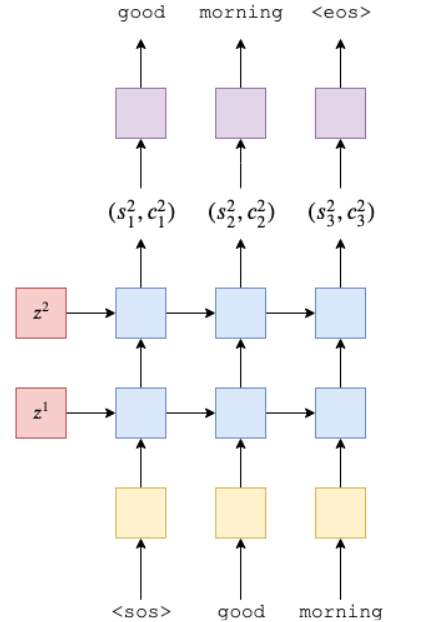


In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, embedding_dim, hidden_dim, num_layers, dropout):
        # Register this module's layers and parameters with PyTorch.
        super().__init__()
        # Number of target-vocabulary tokens, NOT the output sentence length.
        # The Seq2Seq wrapper uses this size when allocating prediction tensors.
        self.output_dim = output_dim

        # A separate English embedding table: one learned vector per target token.
        self.embedding = nn.Embedding(output_dim, embedding_dim, padding_idx=PAD_IDX)
        # Embedding dropout is active during training and disabled in eval mode.
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            embedding_dim,  # Number of features in each input token vector.
            hidden_dim,     # Number of values in each hidden/cell state vector.
            num_layers=num_layers,  # Must match the encoder for direct state transfer.
            # This separate dropout acts between stacked LSTM layers.
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,  # Sequence layout: (batch, time, features).
        )
        # Turn the top layer's output into one raw score per target token.
        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_token, hidden, cell):
        # ONE decoding step for every sentence in the batch.
        # input_token: (B,) — <sos> initially; later, a supplied previous target token.
        # hidden/cell: (num_layers, B, hidden_dim) each.
        # First call: states come from the encoder. Later: from the previous call.

        # Embed IDs: (B,) -> (B, embedding_dim), then apply dropout.
        # unsqueeze(1) adds the time dimension required by the LSTM:
        # (B, embedding_dim) -> (B, 1, embedding_dim).
        embedded = self.dropout(self.embedding(input_token)).unsqueeze(1)  # (B, 1, n_e)

        # Process this token using the supplied states, and update those states.
        # output: top-layer output, shape (B, 1, hidden_dim).
        # hidden/cell: updated states from ALL layers, (num_layers, B, hidden_dim).
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))

        # Remove only the one-step time axis: (B, 1, hidden_dim) -> (B, hidden_dim).
        # Project to vocabulary scores: (B, hidden_dim) -> (B, output_dim).
        # Keep raw logits: CrossEntropyLoss applies log-softmax internally.
        logits = self.output_layer(output.squeeze(1))  # (B, |V_y|)

        # The caller selects the next input token and passes these updated states
        # back on the next step. This method does not loop or choose tokens itself.
        return logits, hidden, cell


## 9. Joining the models and teacher forcing

The complete model first encodes the source and then loops over target positions. After predicting a token, it must choose the next decoder input:

- **Teacher forcing:** use the correct target token. This provides a clean learning signal.
- **Autoregressive feedback:** use the model's own predicted token. This matches inference but can compound early errors.

A teacher-forcing ratio of 0.5 chooses the ground-truth token with probability 0.5 for each example and step. Evaluation uses a ratio of 0.0. The difference between training on correct histories and predicting from imperfect histories is often called **exposure bias**.

In [ ]:
# Combine the encoder and decoder into one model trained jointly.
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        # Register the two modules so their parameters belong to this model.
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, source, source_lengths, target, teacher_forcing_ratio=0.5):
        # source: (B, T_x); source_lengths: (B,); target: (B, T_y).
        # target includes <sos>, <eos>, and any padding added for this batch.
        # Ratio 1.0 always uses correct previous tokens; 0.0 uses predictions.
        batch_size, target_length = target.shape

        # Reserve one vocabulary-score vector for each target position and sentence.
        # Shape: (B, T_y, target vocabulary size), on the same device as source.
        # Position 0 stays zero: <sos> is supplied as input, not predicted.
        outputs = torch.zeros(
            batch_size, target_length, self.decoder.output_dim, device=source.device
        )

        # Read the entire source batch ONCE. The encoder's final states initialize
        # the decoder: hidden and cell each have shape (num_layers, B, hidden_dim).
        hidden, cell = self.encoder(source, source_lengths)
        # Select the first token from every target row: a vector of <sos> IDs, (B,).
        input_token = target[:, 0]  # every target begins with <sos>

        # Start at position 1: use <sos> to predict the first actual target token.
        # This forward pass uses the padded reference length, not an <eos> stop rule.
        # The separate translate() function later handles stopping during inference.
        for t in range(1, target_length):
            # One decoding step for every sentence. Reuse the updated states on
            # the next iteration; do not reset them to the encoder states.
            logits, hidden, cell = self.decoder(input_token, hidden, cell)
            # Store scores predicting target[:, t]. logits has shape (B, vocabulary).
            # At a single time step, the decoder outputs for each sentence in the batch a
            # vector of raw scores for every token in the target vocabulary. 
            outputs[:, t, :] = logits

            # Pick the highest-scoring token ID for each sentence: shape (B,).
            # This discrete choice is only for feedback; loss uses the raw logits.
            predicted_token = logits.argmax(dim=1)

            # Draw a separate random number for each sentence at EACH time step.
            # Comparing with the ratio gives a Boolean mask of shape (B,).
            # At ratio 0.5, each entry has a 50% chance of being True.
            use_teacher = torch.rand(batch_size, device=source.device) < teacher_forcing_ratio

            # Choose the NEXT step's input independently for each sentence:
            # True -> correct token at position t; False -> model's prediction.
            # Example: after predicting "book", feed the correct "book" under
            # teacher forcing, or the predicted token (perhaps "car") otherwise.
            input_token = torch.where(use_teacher, target[:, t], predicted_token)

        # Return all logits. The loss later compares outputs[:, 1:] with target[:, 1:]
        # and ignores target <pad> positions; the unused <sos> slot is excluded.
        return outputs


## 10. Initialize the model and inspect tensor flow

The encoder and decoder must use compatible hidden sizes and layer counts because the encoder states directly initialize the decoder. Their embedding sizes may differ.

In [ ]:
EMBEDDING_DIM = 32
HIDDEN_DIM = 64
NUM_LAYERS = 2
DROPOUT = 0.2

encoder = Encoder(len(source_itos), EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
decoder = Decoder(len(target_itos), EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
model = Seq2Seq(encoder, decoder).to(device)

def initialize_weights(module):
    if isinstance(module, (nn.Linear, nn.Embedding)):
        nn.init.uniform_(module.weight, -0.08, 0.08)
    if isinstance(module, nn.Linear) and module.bias is not None:
        nn.init.zeros_(module.bias)

model.apply(initialize_weights)

parameter_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f"trainable parameters: {parameter_count:,}")

source_batch, source_lengths, target_batch = next(iter(train_loader))
source_batch = source_batch.to(device)
target_batch = target_batch.to(device)
with torch.no_grad():
    output = model(source_batch, source_lengths, target_batch, teacher_forcing_ratio=0.0)
print("model output shape:", output.shape, "= (batch, target length, target vocabulary)")

## 11. Loss, optimization, and training

At each non-initial target position, the model predicts a categorical distribution over the target vocabulary. We flatten the time and batch dimensions before applying cross-entropy.

The `<sos>` position is excluded because the decoder receives it rather than predicts it. Padding is ignored with `ignore_index=PAD_IDX`. Gradient clipping limits exploding gradients, which can still affect gated RNNs.

In [ ]:
# Compare raw vocabulary scores (logits) with the correct target token IDs.
# CrossEntropyLoss handles log-softmax internally; do not apply softmax first.
# Ignore positions whose correct token is <pad>. By default, average the loss
# over the remaining target tokens in this batch.
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
# Adam updates the encoder and decoder parameters using their gradients.
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

def run_epoch(model, loader, optimizer=None, teacher_forcing_ratio=0.0, clip=1.0):
    # One epoch is one pass through all batches in loader.
    # Pass an optimizer to train; leave it as None to evaluate without updates.
    training = optimizer is not None
    # True enables training behavior (such as dropout); False enables eval mode.
    # This mode switch does not itself enable or disable gradient tracking.
    model.train(training)
    total_loss = 0.0

    for source, source_lengths, target in loader:
        # Move token tensors to the model's device (CPU or GPU).
        # Leave source_lengths on the CPU for packed-sequence processing.
        source, target = source.to(device), target.to(device)

        if training:
            # Clear previous gradients: PyTorch otherwise accumulates them.
            optimizer.zero_grad()

        # Record operations for backpropagation only when training.
        # Evaluation needs predictions and loss, but no gradient graph.
        with torch.set_grad_enabled(training):
            # Encode the source, then decode the target sequence step by step.
            # Teacher forcing controls how often the correct previous token
            # is used as the next decoder input instead of the predicted token.
            # output shape: (B, T, V) = (batch size, target length, vocabulary size).
            output = model(source, source_lengths, target, teacher_forcing_ratio)
            # Skip position 0 (<sos>): it is supplied as input, not predicted.
            # output[:, 1:] is the same as output[:, 1:, :] which returns [B, T-1, V].
            # Flatten batch and time so each row holds one token's V scores:
            # (B, T - 1, V) -> (B * (T - 1), V). -1 infers the row count.
            # output.size(-1) is the vocabulary size
            logits = output[:, 1:, :].reshape(-1, output.size(-1)) # logits shape: (B * (T - 1), V)
            # Flatten the correct token IDs in the same order, so every score
            # row above matches its label: (B, T - 1) -> (B * (T - 1),).
            expected = target[:, 1:].reshape(-1)
            # Compute one scalar loss for this batch, ignoring <pad> labels.
            loss = criterion(logits, expected)

            if training:
                # Backpropagate the loss to compute parameter gradients.
                loss.backward()
                # If the combined gradient norm exceeds clip, scale gradients
                # down to that limit to help prevent exploding gradients.
                nn.utils.clip_grad_norm_(model.parameters(), clip)
                # Use the clipped gradients to update the model's parameters.
                optimizer.step()

        # Extract a Python number for reporting, without retaining the graph.
        total_loss += loss.item()

    # Average the batch losses. Each batch has equal weight here, even if
    # batches contain different numbers of non-padding target tokens.
    return total_loss / len(loader)

### Understanding validation cross-entropy

**Validation cross-entropy measures how much probability the encoder–decoder assigns to the correct reference tokens on held-out sentences.** It uses the same loss function as training, but evaluates the model without updating its weights. Lower loss means higher probability assigned to the correct tokens on average.

For one reference token, the loss is $-\ln P(\text{correct token})$:

| Probability assigned to the correct token | Token cross-entropy |
|---|---:|
| 0.9 | 0.105 |
| 0.5 | 0.693 |
| 0.1 | 2.303 |

**Loss is not accuracy:** a loss of `0.693` does not mean 50% of predictions are correct.

In `run_epoch(model, valid_loader)`, the decoder receives its own previous predictions (`teacher_forcing_ratio=0.0`), while reference tokens provide the labels for loss calculation. Padding and the initial `<sos>` are excluded; `<eos>` is included. The reported loss averages token losses within each batch, then averages batches equally.

- **Judge the trend, not an absolute threshold.** There is no universal good loss. Compare checkpoints under the same validation setup. Falling validation loss suggests improvement; falling training loss with rising validation loss can indicate overfitting. Training and validation here also differ in teacher forcing and dropout.
- **Use it to select weights.** The loop below saves and restores the checkpoint with the lowest validation loss.
- **Check translation quality too.** Loss measures reference-token probability, not meaning preservation or fluency. Inspect generated translations and use a metric such as BLEU alongside it.

### Understanding perplexity

**Perplexity is the exponential of cross-entropy loss.** The notebook calculates it as:

```python
perplexity = math.exp(min(valid_loss, 20))
```

For validation losses below 20, this is simply $e^{\text{valid loss}}$:

For one correct token with probability $p$:

$$
\text{Cross-entropy}=-\ln p
\qquad\Longrightarrow\qquad
\text{Perplexity}=e^{-\ln p}=\frac{1}{p}
$$

| Validation cross-entropy | Perplexity | Equivalent correct-token probability ($e^{-\text{loss}}$) |
|---|---:|---:|
| 0 | 1 | 100% |
| 0.693 | ≈ 2 | ≈ 50% |
| 1.609 | ≈ 5 | ≈ 20% |
| 2.303 | ≈ 10 | ≈ 10% |

The probability column shows the constant probability that would give the same loss if assigned to every correct token. Actual token probabilities can vary; this is not token accuracy.

#### Example: why a perplexity of 5?

Suppose the reference translation is **“i see you”**. For simplicity, consider only these three word predictions. At each step, the decoder produces a probability distribution over the vocabulary. We look at the probability it assigns to the correct reference word:

| Step | Correct reference word | Probability assigned to it | Token loss: $-\ln P$ |
|---|---|---:|---:|
| 1 | i | 0.2 | ≈ 1.609 |
| 2 | see | 0.2 | ≈ 1.609 |
| 3 | you | 0.2 | ≈ 1.609 |

The average cross-entropy is `1.609`, so perplexity is $e^{1.609} \approx 5$. **Here, perplexity 5 comes from giving each correct word a 20% probability.** It does not tell us whether those words were the highest-probability predictions.

The probabilities do not have to be the same at every step. For example, assigning correct tokens probabilities `0.1` and `0.4` across two steps gives:

$$
\text{Average loss} = \frac{-\ln(0.1)-\ln(0.4)}{2} = \ln(5),
\qquad \text{perplexity} = 5.
$$

So **perplexity 5 means the average loss is equivalent to giving every correct token a 20% probability**, even though individual correct tokens may receive higher or lower probabilities. It does not mean the model chooses among exactly five words or has 20% accuracy.

**Why report perplexity?** Its advantage is interpretability: a perplexity of 5 can be understood through the example above as the same average loss as assigning each correct token a 20% probability, whereas cross-entropy expresses this in logarithmic units. Perplexity is not a better or independent measure of performance. 

- **Lower is better.** Perplexity 1 means probability 1 is assigned to every correct token. Perplexity is not accuracy; it expresses cross-entropy on a different scale and adds no new information.

In [ ]:
EPOCHS = 60
best_valid_loss = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(
        model, train_loader, optimizer, teacher_forcing_ratio=0.5, clip=1.0
    )
    valid_loss = run_epoch(model, valid_loader)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_state = copy.deepcopy(model.state_dict())

    if epoch == 1 or epoch % 10 == 0:
        perplexity = math.exp(min(valid_loss, 20))
        print(
            f"epoch {epoch:02d} | train loss {train_loss:.3f} | "
            f"valid loss {valid_loss:.3f} | valid perplexity {perplexity:.2f}"
        )

model.load_state_dict(best_state)

## 12. Autoregressive inference

**Autoregressive inference** generates an output sequence one token at a time, using each generated token as the decoder's input for the next step. In this LSTM encoder–decoder, predictions depend on the source sentence and previously generated tokens through the decoder's evolving hidden and cell states. At inference time there is no target sentence and no teacher forcing.

### Techniques for autoregressive inference

Autoregressive inference describes the feedback process; the decoding technique determines how tokens or candidate sequences are selected.

- **Greedy decoding:** Select the highest-logit (equivalently, highest-probability) token at each step. It is simple and fast, but a locally best choice need not produce the highest-probability complete sequence.
- **Top-k sampling:** Keep only the `k` highest-probability tokens, renormalize their probabilities to sum to 1, and sample the next token from that restricted distribution. This allows variation while excluding lower-ranked tokens.
- **Beam search:** Keep up to `k` candidate partial sequences (the beam width). At each step, expand the active candidates and retain the best-scoring candidates using cumulative token log-probabilities, often with length normalization. Each candidate carries its own decoder hidden and cell states. This explores more alternatives than greedy decoding but requires more computation and still does not guarantee the best complete sequence.
- **Random sampling:** Apply softmax to the logits and sample the next token from the full vocabulary distribution. More probable tokens are more likely to be chosen, but low-probability tokens can also be selected, increasing variety and the risk of errors.

### Greedy decoding in this notebook

The `translate()` function below uses greedy decoding:

1. Encode the source once to initialize the decoder's hidden and cell states.
2. Give `<sos>` to the decoder.
3. Select the highest-logit token using `argmax`.
4. Feed that prediction back as the next input, carrying forward the updated hidden and cell states.
5. Stop at `<eos>` or a maximum length.


In [ ]:
# Disable gradient tracking for this function: inference does not train the model.
@torch.no_grad()
def translate(model, sentence, max_output_length=20):
    # Use evaluation behavior (for example, turn off dropout).
    # eval() controls layer behavior; no_grad() above controls gradient tracking.
    model.eval()
    # Convert the source sentence to token IDs, then add a batch dimension:
    # (source_length,) -> (1, source_length). Translate one sentence at a time.
    # Move the IDs to the same device used by the model.
    source = numericalize(sentence, source_stoi).unsqueeze(0).to(device)
    # One source length for this one-sentence batch. Keep lengths on the CPU
    # for the encoder's packed-sequence processing.
    source_lengths = torch.tensor([source.size(1)])
    # Encode the source ONCE. Its final hidden and cell states initialize
    # the decoder; both have shape (num_layers, 1, hidden_dim).
    hidden, cell = model.encoder(source, source_lengths)

    # Start decoding with <sos>. Shape (1,) means one token for one sentence.
    input_token = torch.tensor([SOS_IDX], device=device)
    # Collect predicted words in order; <sos> is not part of the returned text.
    generated_tokens = []

    # Generate at most this many tokens to avoid an endless loop if the model
    # never predicts <eos>. The loop counter is unused, hence the name _.
    for _ in range(max_output_length):
        # Predict the next token's vocabulary scores: logits shape (1, V).
        # Carry the UPDATED hidden and cell states into the next iteration
        # so the decoder retains information about earlier decoding steps.
        logits, hidden, cell = model.decoder(input_token, hidden, cell)
        # Greedy decoding: choose the highest-scoring vocabulary ID.
        # argmax(dim=1) returns shape (1,); item() extracts a Python integer.
        # Softmax is unnecessary: it would not change which score is largest.
        predicted_index = logits.argmax(dim=1).item()
        # <eos> means the sentence is complete. Stop without adding it to text.
        if predicted_index == EOS_IDX:
            break
        # Convert the predicted ID back to a word and save it.
        generated_tokens.append(target_itos[predicted_index])
        # Feed our own prediction into the next decoding step, shape (1,).
        # This feedback makes inference autoregressive: no correct target
        # tokens are supplied, so there is no teacher forcing.
        input_token = torch.tensor([predicted_index], device=device)

    # Return a list of words, ending at <eos> or the output-length limit.
    return generated_tokens

# Translate each test source. The expected translation is only displayed
# for comparison; it is never passed into translate().
for source, expected in test_pairs:
    # Join the generated word list into a space-separated sentence.
    prediction = " ".join(translate(model, source))
    print(f"source:   {source}")
    print(f"expected: {expected}")
    # Add a space before nonempty predictions, then a blank line between cases.
    print(f"predicted:{' ' if prediction else ''}{prediction}\n")


## 13. Evaluation

Loss measures token prediction under the model, while translation quality is a sequence-level question. Useful metrics include:

- **Perplexity:** exponentiated average token loss; lower is better.
- **Token accuracy:** easy to interpret but does not reward valid alternative translations.
- **Exact match:** strict; mainly useful for controlled tasks.
- **BLEU:** compares matching n-grams with one or more reference translations.

Automatic metrics are imperfect and should be accompanied by example inspection. Our tiny synthetic split is suitable for checking the implementation, not for making claims about translation quality.

In [ ]:
test_loss = run_epoch(model, test_loader)
exact_matches = sum(
    translate(model, source) == tokenize(expected) for source, expected in test_pairs
)
print(f"test loss:       {test_loss:.3f}")
print(f"test perplexity: {math.exp(min(test_loss, 20)):.2f}")
print(f"exact match:     {exact_matches}/{len(test_pairs)}")

## 14. BLEU: evaluating generated translations

**BLEU (Bilingual evaluation understudy) compares generated English translations with reference English translations using overlapping word sequences.** Unlike cross-entropy and perplexity, it evaluates the generated text rather than the probabilities assigned to reference tokens.

In this notebook, `" ".join(translate(model, source))` is the prediction and `expected` is its reference. BLEU does not directly examine the German source.

### 1. Count matching n-grams

An **n-gram** is a sequence of `n` consecutive tokens. Standard BLEU-4 combines modified precisions for 1-, 2-, 3-, and 4-grams. Modified precision clips each predicted n-gram's match count to its reference count: repeating a word cannot earn unlimited credit. See the [original BLEU paper](https://aclanthology.org/P02-1040.pdf).

Consider an illustrative prediction using a sentence pattern from our dataset:

```text
German:     heute sehe ich das haus
Reference:  today i see the house
Prediction: today i see the book
```

| n-gram size | Prediction's n-grams | Matching / total | Precision |
|---|---|---:|---:|
| 1 | `today`, `i`, `see`, `the`, `book` | 4 / 5 | 0.80 |
| 2 | `today i`, `i see`, `see the`, `the book` | 3 / 4 | 0.75 |
| 3 | `today i see`, `i see the`, `see the book` | 2 / 3 | ≈ 0.667 |
| 4 | `today i see the`, `i see the book` | 1 / 2 | 0.50 |

The wrong noun affects every n-gram containing it. Single-word matches capture vocabulary overlap; longer matches also capture local word order. If a prediction repeated `the` five times but the reference contained it once, only one occurrence would receive unigram credit.

### 2. Combine the precisions

BLEU-4 uses a geometric mean, multiplied by a brevity penalty (BP):

$$
\text{BLEU}=\text{BP}\times(p_1p_2p_3p_4)^{1/4}.
$$

Here, $p_n$ is the modified n-gram precision. Our prediction and reference both contain five words, so BP is 1:

$$
\text{BLEU}=1\times\left(\frac45\times\frac34\times\frac23\times\frac12\right)^{1/4}
\approx 0.669.
$$

That is **66.9 on a 0–100 scale**, not 66.9% accuracy. Without smoothing, a zero precision at any included order makes BLEU zero.

### 3. Penalize translations that are too short

Consider a different prediction:

```text
Reference:  today i see the house
Prediction: today i see the
```

Every generated n-gram matches, but `house` is missing. For candidate length $c$ and reference length $r$, the brevity penalty is:

$$
\text{BP}=\begin{cases}
1 & c\ge r,\\
e^{1-r/c} & 0<c<r.
\end{cases}
$$

Here, $c=4$ and $r=5$, giving $\text{BP}=e^{1-5/4}\approx0.779$. Since all four precisions are 1, BLEU is approximately **77.9**, rather than 100. An empty prediction scores zero.

This omission scores higher than the wrong noun in the earlier example. BLEU's ranking therefore need not match a human judgment of error severity.

### 4. Calculate corpus BLEU for this notebook

**Corpus BLEU aggregates matching and total n-gram counts across the test translations**, with clipping performed against each sentence's own reference. It also uses total candidate and reference lengths for BP. N-grams never cross sentence boundaries. Corpus BLEU is not the average of individual sentence BLEU scores.

After restoring the best model weights and defining `translate()`, the following code evaluates all four test pairs. Install SacreBLEU once in the notebook environment if needed:

```python
%pip install sacrebleu
```

```python
from sacrebleu.metrics import BLEU

predictions = []
references = []

for source, expected in test_pairs:
    predictions.append(" ".join(translate(model, source)))
    references.append(expected)

bleu = BLEU()
# One reference set, containing one English reference per prediction.
result = bleu.corpus_score(predictions, [references])

print(f"Test BLEU: {result.score:.2f}")
print(bleu.get_signature())
```

The code is shown as an example; it must be run in a code cell to calculate a score. SacreBLEU reports BLEU on a 0–100 scale and records tokenization and smoothing settings in its signature. Keep these settings consistent when comparing models. Its default smoothing can yield nonzero scores when unsmoothed BLEU would be zero. See the [SacreBLEU documentation](https://github.com/mjpost/sacrebleu).

#### Worked example: aggregating two sentence pairs

**Corpus BLEU sums n-gram counts across sentences, then calculates one score. It does not average sentence BLEU scores.** Consider these illustrative translations:

| Pair | Reference | Model prediction |
|---|---|---|
| 1 | `today i see the house` | `today i see the book` |
| 2 | `the car is red` | `the car is red` |

**Step 1: Count matches within each pair.** Compare each prediction only with its own reference, clipping repeated matches to the reference's counts.

| n-gram size | Pair 1: matches / total | Pair 2: matches / total |
|---|---:|---:|
| 1 | 4 / 5 | 4 / 4 |
| 2 | 3 / 4 | 3 / 3 |
| 3 | 2 / 3 | 2 / 2 |
| 4 | 1 / 2 | 1 / 1 |

For example, Pair 1 has two predicted 4-grams: `today i see the` matches, while `i see the book` does not. A prediction cannot earn credit by matching another sentence's reference, and n-grams never cross sentence boundaries.

**Step 2: Sum counts, then calculate corpus precisions.**

$$
p_n=\frac{\text{Total clipped matches across sentence pairs}}{\text{Total predicted n-grams across sentence pairs}}.
$$

| n-gram size | Corpus matches | Corpus total | Corpus precision |
|---|---:|---:|---:|
| 1 | $4+4=8$ | $5+4=9$ | $p_1=8/9$ |
| 2 | $3+3=6$ | $4+3=7$ | $p_2=6/7$ |
| 3 | $2+2=4$ | $3+2=5$ | $p_3=4/5$ |
| 4 | $1+1=2$ | $2+1=3$ | $p_4=2/3$ |

We sum the match counts and total counts separately, rather than averaging sentence precisions.

**Step 3: Calculate the corpus brevity penalty.** With one reference per prediction, add all prediction lengths to obtain $c$ and all reference lengths to obtain $r$:

$$
c=5+4=9,\qquad r=5+4=9.
$$

Apply the same brevity-penalty formula as above using these corpus totals. Since $c=r$, $\text{BP}=1$.

**Step 4: Combine the corpus precisions.**

$$
\begin{aligned}
\text{BLEU}
&=\text{BP}\times(p_1p_2p_3p_4)^{1/4}\\
&=1\times\left(\frac89\times\frac67\times\frac45\times\frac23\right)^{1/4}\\
&\approx0.798.
\end{aligned}
$$

The corpus BLEU is approximately **79.8 on a 0–100 scale**, not 79.8% accuracy. This example uses the unsmoothed BLEU-4 formula; all four precisions are nonzero, so no smoothing is needed.

In the sample code, `bleu.corpus_score(predictions, [references])` performs this aggregation across **all four test translations**. The outer brackets indicate one reference set containing one reference sentence per prediction.

### 5. Interpret the result

- **Higher is better under the same evaluation setup.** BLEU measures reference overlap, not the percentage of correct translations.
- **Valid alternative wording can lose credit.** For example, `i see the home` may express a similar meaning to `i see the house` but has fewer exact matches.
- **Inspect translations alongside the score.** Look for incorrect nouns or colors, missing words, and word-order errors. Use validation data for model choices and reserve the test set for final evaluation.


## 15. Limitations and the path to attention

This model forces the encoder to compress the complete source into the fixed-size pair $(h_T,c_T)$. As the source grows, details from early positions can be difficult to preserve. This is the **fixed-context bottleneck**.

An attention-based decoder receives all encoder outputs $(h_1,\ldots,h_{T_x})$ and learns which source positions to consult at each decoding step. Other limitations of this first model include:

- greedy rather than beam-search decoding;
- word-level rather than subword tokenization;
- no bidirectional encoder;
- exposure bias from teacher forcing; and
- a tiny synthetic corpus with little linguistic variety.

## 16. Scaling the same pipeline to Multi30k

To turn this lesson into a real German-to-English experiment, keep the model and training structure but replace the data layer:

1. Load train, validation, and test splits from Multi30k.
2. Use German and English tokenizers or train a shared subword tokenizer.
3. Build vocabularies from the training split only.
4. Numericalize every example and retain `<sos>`, `<eos>`, `<unk>`, and `<pad>`.
5. Batch with padding and true source lengths.
6. Increase embedding/hidden dimensions and train for more epochs.
7. Save the state with the best validation loss.
8. Report BLEU on the test split only after model choices are finalized.

The architectural lesson does not change: the encoder produces context states, the decoder generates conditionally on those states, and all parameters are trained jointly from target-token loss.

## 17. Summary and exercises

### Summary

- The encoder converts a variable-length source into final LSTM states $(h_T,c_T)$.
- Those states initialize a decoder that generates target tokens sequentially.
- Teacher forcing helps training, while inference feeds predictions back into the decoder.
- Padding must be excluded from the loss, and source lengths let the encoder ignore padded steps.
- Gradient clipping improves recurrent-training stability.
- Fixed context is a bottleneck; attention is the natural next step.

### Suggested exercises

1. Set the teacher-forcing ratio to 0 and 1. Compare convergence and inference.
2. Print `hidden.shape` and `cell.shape` inside both modules and explain every dimension.
3. Remove packed sequences and observe why padding can affect the encoder context.
4. Add token accuracy that ignores `<pad>`.
5. Replace greedy decoding with a small beam search.
6. Modify the encoder to return all outputs in preparation for attention.